#What is BM25?

BM25 (Best Match 25) is a ranking function used in information retrieval to find and rank documents based on how relevant they are to a search query. It improves upon the traditional TF-IDF approach.

#Working:
BM25 scores a document against a query by combining three ideas:

1. Term Frequency (TF):

   - Words that appear more often in a document are usually more important.

   - But BM25 saturates this effect (the first few occurrences matter more than later ones).

2. Inverse Document Frequency (IDF):

    - Rare terms across the whole collection are more informative than common ones.

    - Example: "satellite" is more useful than "the".

3. Document Length Normalization:

    - Very long documents naturally have more words, so BM25 normalizes by length.

    - Prevents long documents from always being ranked higher just because they contain more terms.

# Part 1: Basic Approach with tiny corpus:
Ranking the sample docs based on the user query, higher rank indicates that the doc is more relevant to user query.

In [ ]:
pip install rank-bm25

In [ ]:
from rank_bm25 import BM25Okapi

In [ ]:
# sample docs (corpus)
corpus = [
    "Machine learning is a field of artificial intelligence",
    "Deep learning is a subset of machine learning",
    "Natural language processing is a part of AI",
    "Reinforcement learning is used in robotics"
]

In [ ]:
# preprocess docs (tokenization)
tokenized_corpus = [doc.lower().split() for doc in corpus]

In [ ]:
# initialize BM25
bm25 = BM25Okapi(tokenized_corpus)

In [ ]:
# Query
query = "deep learing in AI"
tokenized_query = query.lower().split()

In [ ]:
# get docs score
docscores = bm25.get_scores(tokenized_query)

In [ ]:
# Rank documents
results = bm25.get_top_n(tokenized_query, corpus, n=3)

In [ ]:
print("Scores:", docscores)
print("Top results:", results)

Scores: [0.         0.82261928 0.82261928 0.93109655]
Top results: ['Reinforcement learning is used in robotics', 'Natural language processing is a part of AI', 'Deep learning is a subset of machine learning']


#Part 2:
Using real word dataset:
- The Newsgroups dataset

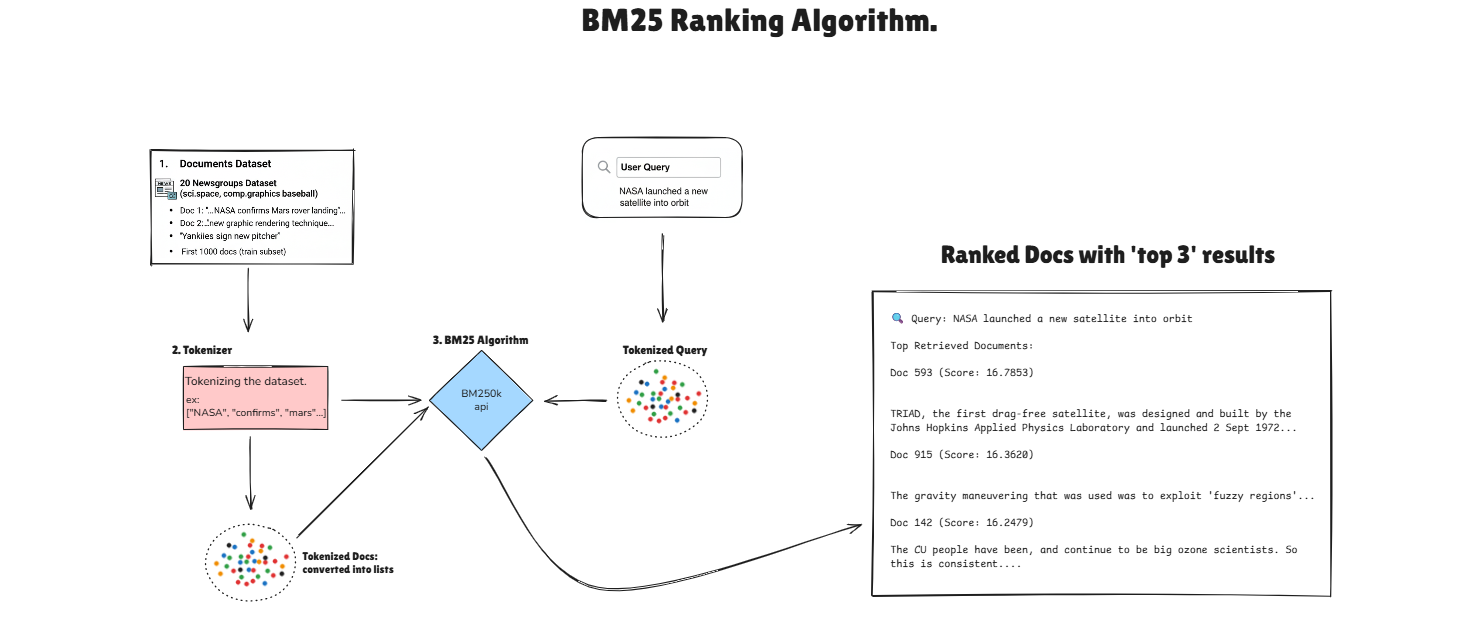

In [ ]:
from IPython.display import Image
display(Image(filename="/content/Screenshot 2025-09-03 154342.png"))

In [ ]:
# imports
from sklearn.datasets import fetch_20newsgroups
from rank_bm25 import BM25Okapi
from transformers import AutoTokenizer

In [ ]:
# 1. Load dataset (subset for simplicity)
newsgroups = fetch_20newsgroups(
    subset="train",
    categories=["sci.space", "comp.graphics", "rec.sport.baseball"],
    remove=("headers", "footers", "quotes")
)

In [ ]:
# Take only first 1000 docs to keep it small
documents = newsgroups.data[:1000]

In [ ]:
# 2. Load Hugging Face tokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(text):
    # Convert to tokens (words/subwords depending on tokenizer)
    return tokenizer.tokenize(text.lower())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:

# Tokenize all documents
tokenized_docs = [tokenize(doc) for doc in documents]

Token indices sequence length is longer than the specified maximum sequence length for this model (7825 > 512). Running this sequence through the model will result in indexing errors


In [ ]:

# 3. Initialize BM25
bm25 = BM25Okapi(tokenized_docs)

In [ ]:
# 4. Query
query = "NASA launched a new satellite into orbit"
tokenized_query = tokenize(query)

In [ ]:
# 5. Get scores
scores = bm25.get_scores(tokenized_query)

In [ ]:
# 6. Rank documents
top_n = 3
top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_n]


In [ ]:
print("\n🔍 Query:", query)
print("\nTop Retrieved Documents:\n")
for idx in top_indices:
    print(f"Doc {idx} (Score: {scores[idx]:.4f})")
    print(documents[idx][:300], "...\n")  # printing first 300 chars


🔍 Query: NASA launched a new satellite into orbit

Top Retrieved Documents:

Doc 593 (Score: 16.7853)


     TRIAD, the first drag-free satellite, was designed and built by the 
Johns Hopkins Applied Physics Laboratory and launched 2 Sept 1972.  The 
satellite was in three sections separated by two booms.  The central section 
housed the DISCOS Disturbance Compensation System, which consisted of a p ...

Doc 915 (Score: 16.3620)


The gravity maneuvering that was used was to exploit 'fuzzy regions'.  These
are described by the inventor as exploiting the second-order perturbations in a
three body system.  The probe was launched into this region for the
earth-moon-sun system, where the perturbations affected it in such a way  ...

Doc 142 (Score: 16.2479)

The CU people have been, and continue to be big ozone scientists. So 
this is consistent. It is also consistent with the new "Comercial 
applications" that NASA and Clinton are pushing so hard. 

Did anyone catch the rocket that was l